In [2]:
# ==========================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [3]:
# ==========================================
# STEP 3 : READ DATASET
# ==========================================

df = pd.read_csv("/content/fashion-mnist_test.csv.zip")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [4]:
# ==========================================
# STEP 4 : EXPLORE DATASET
# ==========================================

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum().sum())

Shape: (10000, 785)

Columns:
Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

Missing Values:
0


In [5]:
# ==========================================
# STEP 5 : INPUT AND OUTPUT
# ==========================================

x = df.drop("label", axis=1)

y = df["label"]

print("Input Shape:")
print(x.shape)

print("\nOutput Shape:")
print(y.shape)

Input Shape:
(10000, 784)

Output Shape:
(10000,)


In [6]:
# ==========================================
# STEP 6 : NORMALIZE INPUT
# ==========================================

x = x / 255.0

print("Minimum value:", x.min().min())

print("Maximum value:", x.max().max())

Minimum value: 0.0
Maximum value: 1.0


In [7]:
# ==========================================
# STEP 7 : TRAIN TEST SPLIT
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Input:", x_train.shape)

print("Testing Input:", x_test.shape)

print("Training Output:", y_train.shape)

print("Testing Output:", y_test.shape)

Training Input: (8000, 784)
Testing Input: (2000, 784)
Training Output: (8000,)
Testing Output: (2000,)


In [8]:
# ==========================================
# STEP 8 : CONVERT TO NUMPY
# ==========================================

x_train = x_train.values
x_test = x_test.values

y_train = y_train.values
y_test = y_test.values

print(x_train.shape)
print(y_train.shape)

(8000, 784)
(8000,)


In [9]:
# ==========================================
# STEP 9 : CONVERT TO PYTORCH TENSORS
# ==========================================

x_train = torch.tensor(
    x_train,
    dtype=torch.float32
)

x_test = torch.tensor(
    x_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: torch.Size([8000, 784])
y_train: torch.Size([8000])
x_test: torch.Size([2000, 784])
y_test: torch.Size([2000])


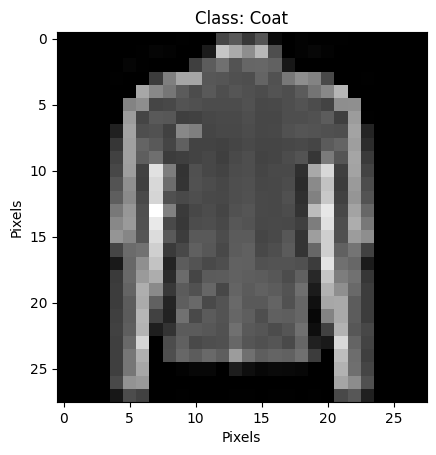

In [10]:
# ==========================================
# STEP 10 : DISPLAY SAMPLE IMAGE
# ==========================================

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

image = x_train[0].reshape(28, 28)

label = y_train[0].item()

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    "Class: " + classes[label]
)

plt.xlabel("Pixels")

plt.ylabel("Pixels")

plt.show()

In [11]:
# ==========================================
# STEP 11 : BUILD ANN MODEL
# ==========================================

class FashionANN(nn.Module):

    def __init__(self):

        super().__init__()

        # Input layer -> Hidden layer
        self.fc1 = nn.Linear(784, 128)

        # Hidden layer -> Hidden layer
        self.fc2 = nn.Linear(128, 64)

        # Hidden layer -> Output layer
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = torch.relu(
            self.fc1(x)
        )

        x = torch.relu(
            self.fc2(x)
        )

        x = self.fc3(x)

        return x

In [12]:
# ==========================================
# STEP 12 : TRAINING FUNCTION
# ==========================================

def train_model(model, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    loss_history = []

    train_accuracy_history = []

    test_accuracy_history = []

    batch_size = 64

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        indices = torch.randperm(
            len(x_train)
        )

        for start in range(
            0,
            len(x_train),
            batch_size
        ):

            end = start + batch_size

            batch_indices = indices[start:end]

            images = x_train[
                batch_indices
            ]

            labels = y_train[
                batch_indices
            ]

            # Forward propagation

            outputs = model(images)

            # Calculate loss

            loss = criterion(
                outputs,
                labels
            )

            # Clear gradients

            optimizer.zero_grad()

            # Backpropagation

            loss.backward()

            # Update weights

            optimizer.step()

            total_loss += loss.item()

        # Average loss

        average_loss = total_loss / (
            len(x_train) / batch_size
        )

        # -----------------------------
        # Training Accuracy
        # -----------------------------

        model.eval()

        with torch.no_grad():

            train_outputs = model(
                x_train
            )

            _, train_predicted = torch.max(
                train_outputs,
                1
            )

            train_accuracy = (
                train_predicted == y_train
            ).float().mean().item()

            # -----------------------------
            # Testing Accuracy
            # -----------------------------

            test_outputs = model(
                x_test
            )

            _, test_predicted = torch.max(
                test_outputs,
                1
            )

            test_accuracy = (
                test_predicted == y_test
            ).float().mean().item()

        loss_history.append(
            average_loss
        )

        train_accuracy_history.append(
            train_accuracy
        )

        test_accuracy_history.append(
            test_accuracy
        )

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {average_loss:.4f}, "
            f"Train Accuracy = "
            f"{train_accuracy * 100:.2f}%, "
            f"Test Accuracy = "
            f"{test_accuracy * 100:.2f}%"
        )

    return (
        loss_history,
        train_accuracy_history,
        test_accuracy_history
    )

In [13]:
# ==========================================
# STEP 13 : ADAM OPTIMIZER
# ==========================================

print("================================")
print("TRAINING USING ADAM")
print("================================")

model_adam = FashionANN()

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

adam_loss, adam_train_acc, adam_test_acc = train_model(
    model_adam,
    optimizer_adam,
    epochs=10
)

TRAINING USING ADAM
Epoch 1: Loss = 1.0211, Train Accuracy = 76.84%, Test Accuracy = 76.10%
Epoch 2: Loss = 0.5725, Train Accuracy = 81.14%, Test Accuracy = 79.70%
Epoch 3: Loss = 0.4942, Train Accuracy = 83.47%, Test Accuracy = 80.80%
Epoch 4: Loss = 0.4669, Train Accuracy = 85.26%, Test Accuracy = 82.65%
Epoch 5: Loss = 0.4256, Train Accuracy = 83.64%, Test Accuracy = 79.80%
Epoch 6: Loss = 0.4154, Train Accuracy = 87.10%, Test Accuracy = 83.65%
Epoch 7: Loss = 0.3954, Train Accuracy = 87.10%, Test Accuracy = 83.35%
Epoch 8: Loss = 0.3675, Train Accuracy = 87.85%, Test Accuracy = 84.10%
Epoch 9: Loss = 0.3470, Train Accuracy = 88.61%, Test Accuracy = 84.20%
Epoch 10: Loss = 0.3361, Train Accuracy = 89.31%, Test Accuracy = 85.25%


In [14]:
# ==========================================
# STEP 14 : SGD OPTIMIZER
# ==========================================

print("================================")
print("TRAINING USING SGD")
print("================================")

model_sgd = FashionANN()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01
)

sgd_loss, sgd_train_acc, sgd_test_acc = train_model(
    model_sgd,
    optimizer_sgd,
    epochs=10
)

TRAINING USING SGD
Epoch 1: Loss = 2.2652, Train Accuracy = 34.58%, Test Accuracy = 34.65%
Epoch 2: Loss = 2.1266, Train Accuracy = 38.84%, Test Accuracy = 39.35%
Epoch 3: Loss = 1.8046, Train Accuracy = 61.43%, Test Accuracy = 60.70%
Epoch 4: Loss = 1.4273, Train Accuracy = 63.38%, Test Accuracy = 62.90%
Epoch 5: Loss = 1.1731, Train Accuracy = 64.91%, Test Accuracy = 64.25%
Epoch 6: Loss = 1.0230, Train Accuracy = 65.61%, Test Accuracy = 64.70%
Epoch 7: Loss = 0.9283, Train Accuracy = 65.78%, Test Accuracy = 65.15%
Epoch 8: Loss = 0.8637, Train Accuracy = 68.56%, Test Accuracy = 67.15%
Epoch 9: Loss = 0.8167, Train Accuracy = 69.86%, Test Accuracy = 68.85%
Epoch 10: Loss = 0.7843, Train Accuracy = 71.29%, Test Accuracy = 70.55%


In [15]:
# ==========================================
# STEP 15 : COMPARE ACCURACY
# ==========================================

print("================================")
print("FINAL ACCURACY COMPARISON")
print("================================")

print(
    "Adam Training Accuracy:",
    adam_train_acc[-1] * 100,
    "%"
)

print(
    "Adam Testing Accuracy:",
    adam_test_acc[-1] * 100,
    "%"
)

print()

print(
    "SGD Training Accuracy:",
    sgd_train_acc[-1] * 100,
    "%"
)

print(
    "SGD Testing Accuracy:",
    sgd_test_acc[-1] * 100,
    "%"
)

FINAL ACCURACY COMPARISON
Adam Training Accuracy: 89.31249976158142 %
Adam Testing Accuracy: 85.25000214576721 %

SGD Training Accuracy: 71.28750085830688 %
SGD Testing Accuracy: 70.55000066757202 %


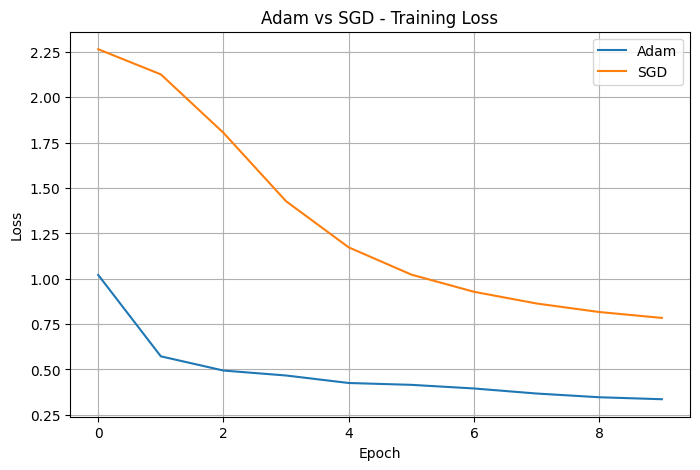

In [16]:
# ==========================================
# STEP 16 : LOSS COMPARISON
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    adam_loss,
    label="Adam"
)

plt.plot(
    sgd_loss,
    label="SGD"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Adam vs SGD - Training Loss"
)

plt.legend()

plt.grid(True)

plt.show()

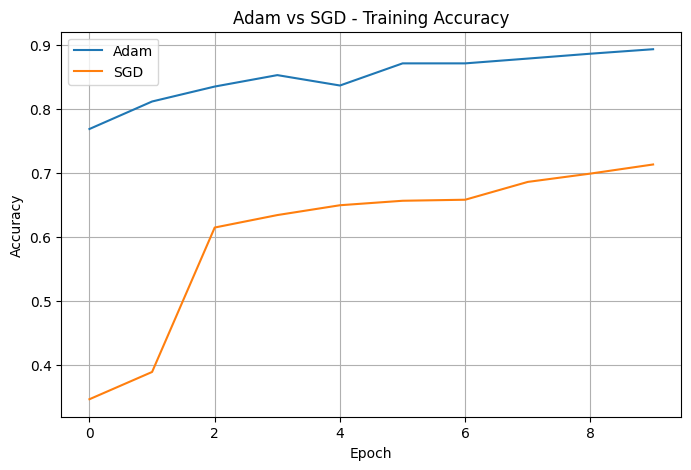

In [17]:
# ==========================================
# STEP 17 : TRAINING ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    adam_train_acc,
    label="Adam"
)

plt.plot(
    sgd_train_acc,
    label="SGD"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Adam vs SGD - Training Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

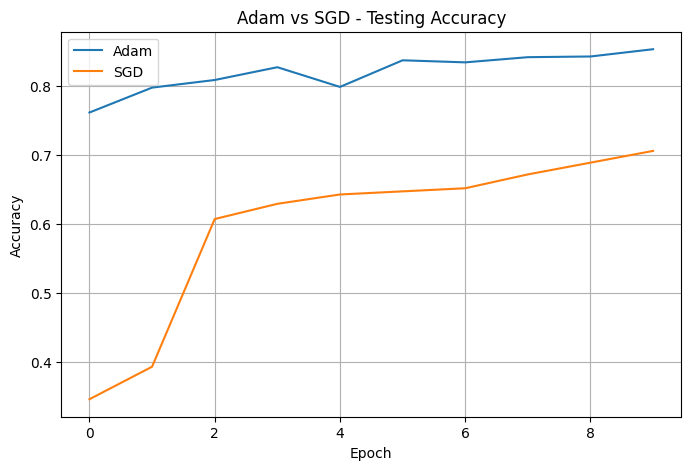

In [18]:
# ==========================================
# STEP 18 : TESTING ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    adam_test_acc,
    label="Adam"
)

plt.plot(
    sgd_test_acc,
    label="SGD"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Adam vs SGD - Testing Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [19]:
# ==========================================
# STEP 19 : EVALUATE ADAM
# ==========================================

model_adam.eval()

with torch.no_grad():

    outputs = model_adam(
        x_test
    )

    _, predicted_adam = torch.max(
        outputs,
        1
    )

adam_accuracy = accuracy_score(
    y_test.numpy(),
    predicted_adam.numpy()
)

print(
    "Adam Test Accuracy:",
    adam_accuracy * 100,
    "%"
)

Adam Test Accuracy: 85.25 %


In [20]:
# ==========================================
# STEP 20 : EVALUATE SGD
# ==========================================

model_sgd.eval()

with torch.no_grad():

    outputs = model_sgd(
        x_test
    )

    _, predicted_sgd = torch.max(
        outputs,
        1
    )

sgd_accuracy = accuracy_score(
    y_test.numpy(),
    predicted_sgd.numpy()
)

print(
    "SGD Test Accuracy:",
    sgd_accuracy * 100,
    "%"
)

SGD Test Accuracy: 70.55 %


In [21]:
# ==========================================
# STEP 21 : ADAM CLASSIFICATION REPORT
# ==========================================

print("ADAM CLASSIFICATION REPORT")

print(
    classification_report(
        y_test.numpy(),
        predicted_adam.numpy(),
        target_names=classes
    )
)

ADAM CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.79      0.80       200
     Trouser       0.98      0.98      0.98       200
    Pullover       0.71      0.78      0.74       200
       Dress       0.85      0.89      0.87       200
        Coat       0.76      0.76      0.76       200
      Sandal       0.93      0.93      0.93       200
       Shirt       0.69      0.60      0.65       200
     Sneaker       0.89      0.91      0.90       200
         Bag       0.97      0.97      0.97       200
  Ankle boot       0.94      0.92      0.93       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [22]:
# ==========================================
# STEP 22 : SGD CLASSIFICATION REPORT
# ==========================================

print("SGD CLASSIFICATION REPORT")

print(
    classification_report(
        y_test.numpy(),
        predicted_sgd.numpy(),
        target_names=classes
    )
)

SGD CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top       0.71      0.72      0.72       200
     Trouser       0.94      0.93      0.93       200
    Pullover       0.51      0.61      0.56       200
       Dress       0.75      0.79      0.77       200
        Coat       0.56      0.69      0.62       200
      Sandal       0.89      0.40      0.55       200
       Shirt       0.33      0.17      0.22       200
     Sneaker       0.63      0.89      0.74       200
         Bag       0.93      0.94      0.93       200
  Ankle boot       0.80      0.93      0.86       200

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.69      2000
weighted avg       0.71      0.71      0.69      2000



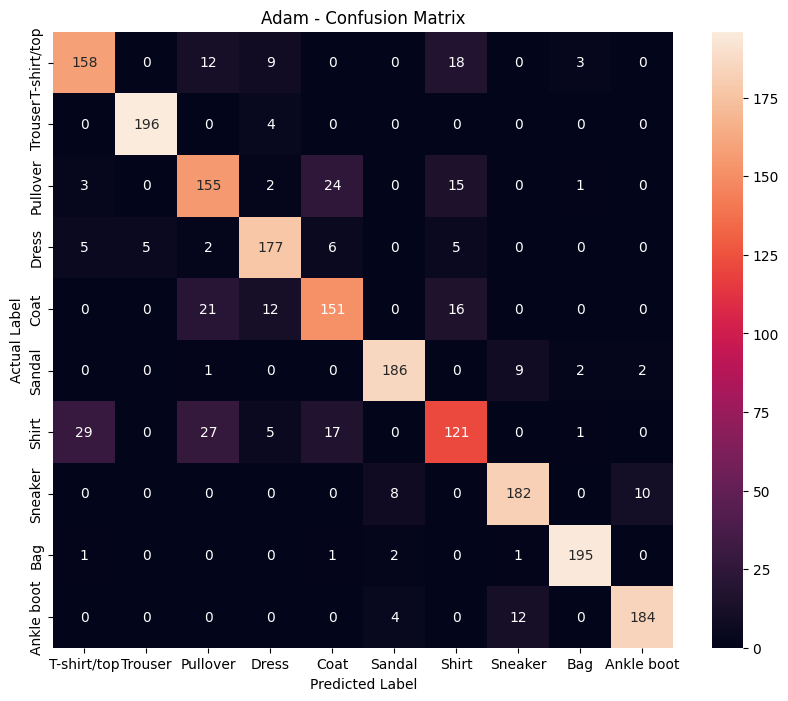

In [23]:
# ==========================================
# STEP 23 : ADAM CONFUSION MATRIX
# ==========================================

cm_adam = confusion_matrix(
    y_test.numpy(),
    predicted_adam.numpy()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_adam,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title(
    "Adam - Confusion Matrix"
)

plt.show()

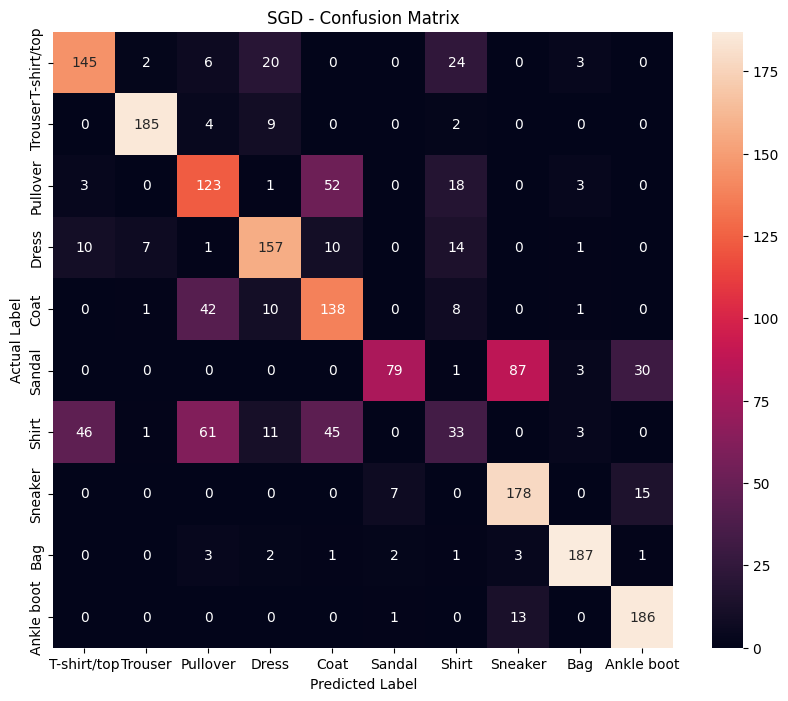

In [24]:
# ==========================================
# STEP 24 : SGD CONFUSION MATRIX
# ==========================================

cm_sgd = confusion_matrix(
    y_test.numpy(),
    predicted_sgd.numpy()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title(
    "SGD - Confusion Matrix"
)

plt.show()

In [25]:
# ==========================================
# STEP 25 : FINAL COMPARISON
# ==========================================

comparison = pd.DataFrame({

    "Optimizer": [
        "Adam",
        "SGD"
    ],

    "Training Accuracy": [
        adam_train_acc[-1] * 100,
        sgd_train_acc[-1] * 100
    ],

    "Testing Accuracy": [
        adam_test_acc[-1] * 100,
        sgd_test_acc[-1] * 100
    ],

    "Final Loss": [
        adam_loss[-1],
        sgd_loss[-1]
    ]
})

print(comparison)

  Optimizer  Training Accuracy  Testing Accuracy  Final Loss
0      Adam          89.312500         85.250002    0.336139
1       SGD          71.287501         70.550001    0.784294


In [26]:
# ==========================================
# STEP 26 : CONCLUSION
# ==========================================

print("""
CONCLUSION
==========

The Fashion-MNIST dataset was loaded using pandas
and preprocessed by separating the input pixel
features and output class labels.

The pixel values were normalized and the dataset
was divided into training and testing data.

An Artificial Neural Network was implemented using
PyTorch with 784 input neurons, 128 and 64 hidden
neurons and 10 output neurons.

Two different optimization algorithms, Adam and SGD,
were applied to train the same ANN model.

The convergence of both optimizers was observed by
comparing their training loss across epochs.

Training accuracy and testing accuracy were also
compared for both optimizers.

Adam generally converges faster because it adapts
the learning rate for the model parameters, while
SGD updates the parameters using a fixed learning
rate.

The optimizer with lower loss, faster convergence
and better testing accuracy can be considered more
effective for this experiment.

Thus, the experiment demonstrates how the choice of
optimizer affects the training speed, convergence
and performance of a neural network.
""")


CONCLUSION

The Fashion-MNIST dataset was loaded using pandas
and preprocessed by separating the input pixel
features and output class labels.

The pixel values were normalized and the dataset
was divided into training and testing data.

An Artificial Neural Network was implemented using
PyTorch with 784 input neurons, 128 and 64 hidden
neurons and 10 output neurons.

Two different optimization algorithms, Adam and SGD,
were applied to train the same ANN model.

The convergence of both optimizers was observed by
comparing their training loss across epochs.

Training accuracy and testing accuracy were also
compared for both optimizers.

Adam generally converges faster because it adapts
the learning rate for the model parameters, while
SGD updates the parameters using a fixed learning
rate.

The optimizer with lower loss, faster convergence
and better testing accuracy can be considered more
effective for this experiment.

Thus, the experiment demonstrates how the choice of
optimizer aff

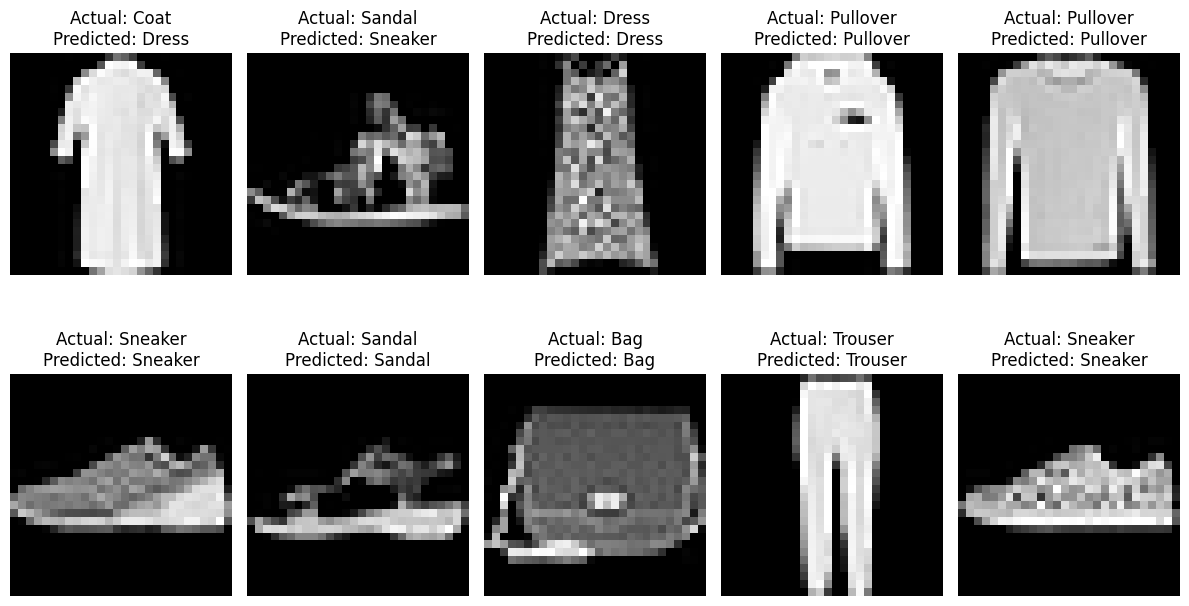

In [27]:
# ==========================================
# STEP 27 : DISPLAY ADAM PREDICTIONS
# ==========================================

model_adam.eval()

with torch.no_grad():

    outputs = model_adam(x_test)

    _, predicted_adam = torch.max(
        outputs,
        1
    )

plt.figure(figsize=(12, 7))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Display image
    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    actual = classes[
        y_test[i].item()
    ]

    predicted = classes[
        predicted_adam[i].item()
    ]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

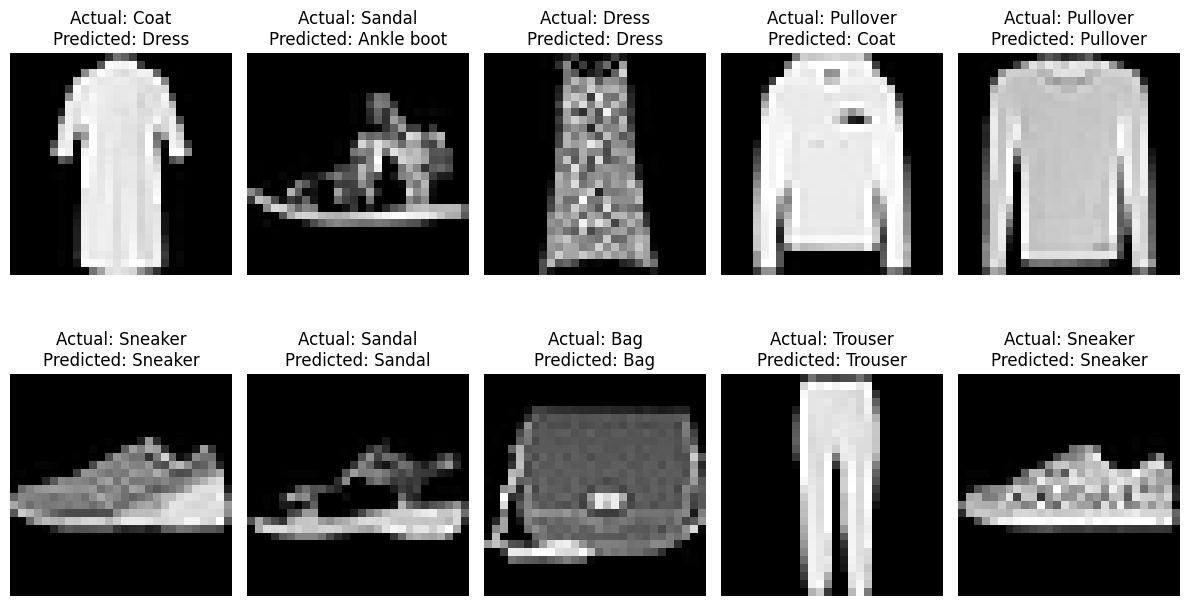

In [28]:
# ==========================================
# STEP 28 : DISPLAY SGD PREDICTIONS
# ==========================================

model_sgd.eval()

with torch.no_grad():

    outputs = model_sgd(x_test)

    _, predicted_sgd = torch.max(
        outputs,
        1
    )

plt.figure(figsize=(12, 7))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Display image
    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    actual = classes[
        y_test[i].item()
    ]

    predicted = classes[
        predicted_sgd[i].item()
    ]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()

plt.show()